## Import required modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sns.set_style("whitegrid")

## Load all dataset using python

In [2]:
train_df = pd.read_csv("./datasets/train.csv")
val_df = pd.read_csv("./datasets/val.csv")
test_df = pd.read_csv("./datasets/test.csv")

train_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2024,0,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,high,extreme,high,low,none,high
1,2022,0,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,moderate,high,moderate,high,none,moderate
2,2024,19,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,low,high,high,low,none,low
3,2022,1,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,no,low,high,low,light,low
4,2022,0,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,high,extreme,high,low,none,high


## Select featuresnd process

In [3]:
selected_columns = [
    "Year",
    "dengue_total",
    "Location",
    "Month",
    "monthly_avg_temperature",
    "avg_daily_rain",
    "avg_daily_humidity",
    "avg_daily_soil_moisture",
    "avg_daily_soil_temperature",
    "avg_daily_snowfall",
    "avg_daily_precipitation"
]

train = train_df[selected_columns].copy()
val = val_df[selected_columns].copy()
test = test_df[selected_columns].copy()

### Categorical Encoding

In [4]:
all_locations = sorted(pd.concat([train["Location"], val["Location"], test["Location"]]).unique())
all_months = sorted(pd.concat([train["Month"], val["Month"], test["Month"]]).unique())

train_loc = pd.get_dummies(train["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
train_month = pd.get_dummies(train["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

val_loc = pd.get_dummies(val["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
val_month = pd.get_dummies(val["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

test_loc = pd.get_dummies(test["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
test_month = pd.get_dummies(test["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

# Combine encoded features back and drop raw categorical columns
train = pd.concat([train.drop(columns=["Month", "Location"]), train_loc, train_month], axis=1)
val = pd.concat([val.drop(columns=["Month", "Location"]), val_loc, val_month], axis=1)
test = pd.concat([test.drop(columns=["Month", "Location"]), test_loc, test_month], axis=1)

## Seperate feature X and target Y

In [5]:
X_train_base = train.drop(columns=["dengue_total"])
y_train = train["dengue_total"]

X_val_base = val.drop(columns=["dengue_total"])
y_val = val["dengue_total"]

X_test_base = test.drop(columns=["dengue_total"])
y_test = test["dengue_total"]

## Create a pipeline for tuning

In [6]:
# Automatic selection of best alpha
lasso_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000) 
)

lasso_pipeline.fit(X_train_base, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](89,)","['Year','monthly_avg_temperature','avg_daily_rain',...,'Nov','Oct','Sep']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,89
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## Evaluations

In [7]:
val_preds_lasso = lasso_pipeline.predict(X_val_base)

print("\nLASSO AUTOMATIC FEATURE SELECTION PERFORMANCE")
print("Best Alpha Selected by CV:", lasso_pipeline.named_steps['lassocv'].alpha_)
print("Validation MSE:", mean_squared_error(y_val, val_preds_lasso))
print("Validation R2 Score:", r2_score(y_val, val_preds_lasso))


LASSO AUTOMATIC FEATURE SELECTION PERFORMANCE
Best Alpha Selected by CV: 0.16569568887386013
Validation MSE: 148503.0286132926
Validation R2 Score: 0.13240175257821685


## Analysis of feature selections

In [9]:
lasso_model = lasso_pipeline.named_steps['lassocv']

feature_weights = pd.DataFrame({
    'Feature': X_train_base.columns,
    'Weight': lasso_model.coef_
})


## Filter non-zero weights

In [ ]:
kept_features = feature_weights[feature_weights['Weight'] != 0].sort_values(by='Weight', ascending=False)
dropped_features = feature_weights[feature_weights['Weight'] == 0]

print(f"\nTotal Features Input: |{X_train_base.shape[1]}")
print(f"Features Kept by Lasso: {len(kept_features)}")
print(f"Features Zeroed Out: {len(dropped_features)}")

print("\nKEPT FEATURES (Sorted by Importance)")


Total Features Input: |89
Features Kept by Lasso: 82
Features Zeroed Out: 7

KEPT FEATURES (Sorted by Importance)


## Plot Top 20 features kept

C:\Users\tikad\AppData\Local\Temp\ipykernel_20572\3618221721.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_weight, x='Weight', y='Feature', palette='Set2')
C:\Users\tikad\AppData\Local\Temp\ipykernel_20572\3618221721.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=locations_weight[0:20], x='Weight', y='Feature', palette='Set2')


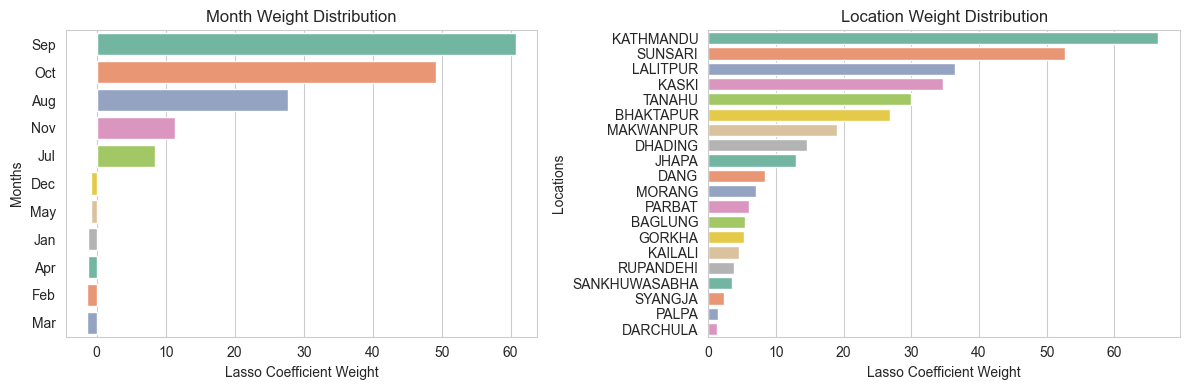

In [26]:
# As per Month
month_weight = kept_features[kept_features["Feature"].isin(train_month.columns.to_list())]
# As per Location
locations_weight = kept_features[kept_features["Feature"].isin(train_loc.columns.to_list())]
# As per Remaining
weather_weight = kept_features[~ kept_features["Feature"].isin(train_month.columns.to_list() + train_loc.columns.to_list() )]

plt.figure(figsize=(12, 4))

# For months
plt.subplot(1,2,1)
plt.title("Month Weight Distribution")
sns.barplot(data=month_weight, x='Weight', y='Feature', palette='Set2')
plt.xlabel("Lasso Coefficient Weight")
plt.ylabel("Months")

# For Location
plt.subplot(1,2,2)
plt.title("Location Weight Distribution")
sns.barplot(data=locations_weight[0:20], x='Weight', y='Feature', palette='Set2')
plt.xlabel("Lasso Coefficient Weight")
plt.ylabel("Locations")

plt.tight_layout()
plt.savefig("./resources/Lasso_Weight_Distribution_for_Month_and_Location.png")
plt.show()

## For Remaining Features plot weight distribution

C:\Users\tikad\AppData\Local\Temp\ipykernel_20572\232831762.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_weight, x='Weight', y='Feature', palette='Set2')


Text(0, 0.5, 'Weather & Year')

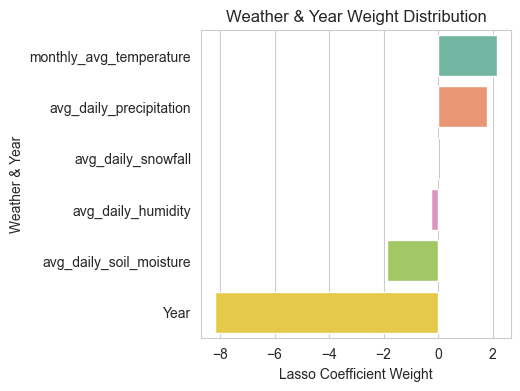

In [29]:
# For remaining
plt.figure(figsize=(4,4))
plt.title("Weather & Year Weight Distribution")
sns.barplot(data=weather_weight, x='Weight', y='Feature', palette='Set2')
plt.xlabel("Lasso Coefficient Weight")
plt.ylabel("Weather & Year")

## Show relation ship with selected data

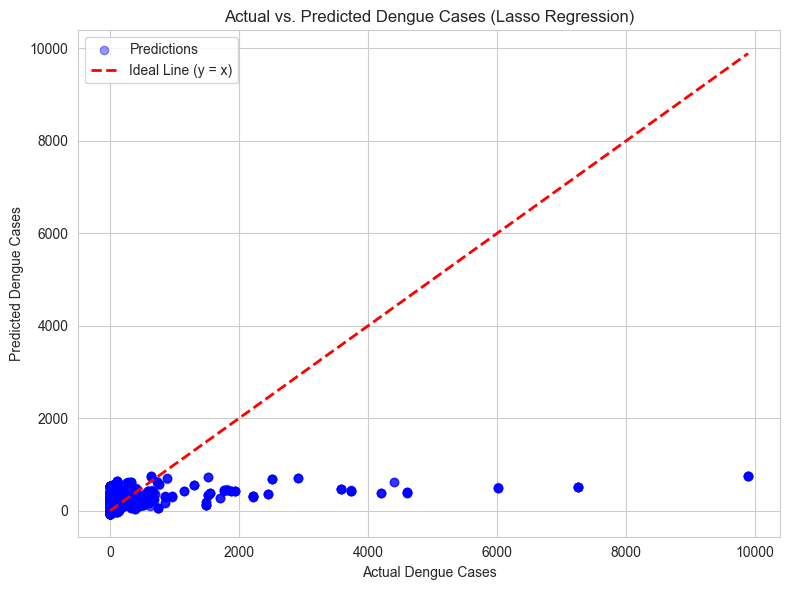

In [ ]:
import matplotlib.pyplot as plt

# predictions on validation data
val_preds = lasso_pipeline.predict(X_val_base)

plt.figure(figsize=(8, 6))
plt.scatter(y_val, val_preds, alpha=0.4, color='blue', label='Predictions')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Ideal Line (y = x)')

plt.title("Actual vs. Predicted Dengue Cases (Lasso Regression)")
plt.xlabel("Actual Dengue Cases")
plt.ylabel("Predicted Dengue Cases")
plt.legend()
plt.tight_layout()
plt.savefig("./resources/Lasso_ACTUAL_VS_PREDICTED.png")
plt.show()